<a href="https://colab.research.google.com/github/dashakudjaeva/HW/blob/hw_2/hw_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Постановка задачи и описание датасета**

Бизнес-постановка: компания сталкивается с высокой текучестью кадров (Attrition). Уход ценных сотрудников ведёт к дополнительным расходам на подбор, адаптацию и потере производительности. Цель – разработать модель машинного обучения, которая по историческим данным о сотруднике предскажет вероятность его увольнения в ближайшем будущем.

ML-постановка: задача бинарной классификации. Целевая переменная Attrition принимает значения Yes (сотрудник уволился) и No (сотрудник остался).

Описание набора данных: датасет HR Employee Attrition (Kaggle) содержит 1470 записей и 35 признаков. Целевая переменная – Attrition.

# **2. Выбор метрики оценки качества**

Классы в данных несбалансированы (около 84% сотрудников остаются, 16% уходят). Accuracy может быть обманчива. Будем использовать F1-меру для положительного класса как основную метрику, а также ROC-AUC для оценки разделяющей способности независимо от порога. F1 сбалансирует точность и полноту, что важно при дисбалансе классов.

# **3. Импорт библиотек и подготовка данных**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix

RANDOM_STATE = 15
np.random.seed(RANDOM_STATE)

# Загрузка данных
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Размер датасета: {df.shape}")

# Удаляем неинформативные столбцы (всегда константные или идентификаторы)
df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1, inplace=True)

# Создаём бинарную целевую переменную
df['Attrition_binary'] = (df['Attrition'] == 'Yes').astype(int)

# Проверка пропусков
print("Пропуски в данных:\n", df.isnull().sum().sum())

Размер датасета: (1470, 35)
Пропуски в данных:
 0


# **4. Разделение на обучающую и тестовую выборки**

Стратификация сохраняет долю класса увольнения в обеих выборках. Соотношение 80/20 – стандартный выбор.

In [26]:
X = df.drop(['Attrition', 'Attrition_binary'], axis=1)
y = df['Attrition_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]}, тестовая: {X_test.shape[0]}")
print(f"Доля положительного класса в обучающей выборке: {y_train.mean():.3f}")
print(f"Доля положительного класса в тестовой выборке: {y_test.mean():.3f}")

Обучающая выборка: 1176, тестовая: 294
Доля положительного класса в обучающей выборке: 0.162
Доля положительного класса в тестовой выборке: 0.160


Обоснование разбиения:

* Соотношение 80/20 обеспечивает достаточный объём для обучения и репрезентативную тестовую выборку.
* Стратификация по Attrition_binary гарантирует, что доля уволившихся (16%) сохранится в обеих выборках, что важно для корректной оценки на несбалансированных данных.

# **5. Константный классификатор (базовый уровень)**

Используем три стратегии, чтобы оценить нижнюю границу качества.

In [27]:
strategies = ['most_frequent', 'stratified', 'uniform']
dummy_results = {}

for strategy in strategies:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)
    y_pred = dummy.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1]) if hasattr(dummy, "predict_proba") else None
    dummy_results[strategy] = {'f1': f1, 'roc_auc': roc_auc}
    print(f"\nСтратегия: {strategy}")
    print(f"F1-score: {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

# Кросс-валидация для most_frequent (подтверждение)
cv_scores = cross_validate(DummyClassifier(strategy='most_frequent'), X_train, y_train,
                           cv=5, scoring='f1', return_train_score=False)
print(f"\nКросс-валидация F1 (most_frequent): {cv_scores['test_score'].mean():.4f} ± {cv_scores['test_score'].std():.4f}")


Стратегия: most_frequent
F1-score: 0.0000
ROC-AUC: 0.5000
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       247
           1       0.00      0.00      0.00        47

    accuracy                           0.84       294
   macro avg       0.42      0.50      0.46       294
weighted avg       0.71      0.84      0.77       294


Стратегия: stratified
F1-score: 0.2062
ROC-AUC: 0.5254
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       247
           1       0.20      0.21      0.21        47

    accuracy                           0.74       294
   macro avg       0.52      0.53      0.52       294
weighted avg       0.74      0.74      0.74       294


Стратегия: uniform
F1-score: 0.2474
ROC-AUC: 0.5000
              precision    recall  f1-score   support

           0       0.84      0.50      0.63       247
           1       0.16      0.51      0.25        47

    accuracy  

Выводы по константным предсказаниям:

* Стратегия most_frequent даёт F1 = 0.00, так как всегда предсказывает класс "0".
* Стратегия stratified предсказывает классы пропорционально частоте, F1 = 0.21.
* Стратегия uniform предсказывает равновероятно, F1 = 0.25.

ROC-AUC для most_frequent и uniform равен 0.5 – модели не разделяют классы.

Таким образом, любая обученная модель должна существенно превзойти эти значения.

# **6. Определение признаков для предобработки**

Числовые признаки выбираем по типу float64/int64, кроме уже удалённых. Категориальные – все объектные столбцы.

In [28]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Категориальные признаки:", categorical_cols)
print("Числовые признаки:", numerical_cols)

Категориальные признаки: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Числовые признаки: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


Выбор числовых и категориальных признаков:

* Числовые признаки имеют разный масштаб и требуют нормализации для линейных моделей и kNN.
* Категориальные признаки будут кодироваться one-hot для использования в моделях.

# **7. Препроцессинг: масштабирование числовых и one-hot кодирование категориальных**

* StandardScaler для числовых – стандартизация (среднее 0, дисперсия 1) необходима для линейных моделей и kNN, чувствительных к масштабу.
* OneHotEncoder с drop='first' – удаляем первый уровень для избежания мультиколлинеарности в линейных моделях.
* handle_unknown='ignore' обеспечивает устойчивость к возможным новым категориям в тестовой выборке.


In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

# **8. Бейзлайновые модели с подбором гиперпараметров**

Выбраны три модели:
* логистическая регрессия (линейная, интерпретируемая),
* дерево решений (нелинейная, интерпретируемая),
* kNN (непараметрическая).

Для каждой выполняется GridSearchCV с 5-кратной кросс-валидацией по F1. Из-за дисбаланса для логистической регрессии и дерева установлен class_weight='balanced'.

In [30]:
models = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
        'param_grid': {'classifier__C': [0.01, 0.1, 1, 10]}
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        'param_grid': {
            'classifier__max_depth': [3, 5, 7, 10, None],
            'classifier__min_samples_split': [2, 5, 10]
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'param_grid': {
            'classifier__n_neighbors': [3, 5, 7, 9, 11],
            'classifier__weights': ['uniform', 'distance']
        }
    }
}

best_models = {}
best_scores = {}

for name, config in models.items():
    print(f"\n=== Настройка {name} ===")
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])
    grid = GridSearchCV(pipeline, config['param_grid'], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_
    best_scores[name] = grid.best_score_

    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Средний F1 на кросс-валидации: {grid.best_score_:.4f}")

    y_pred = grid.predict(X_test)
    test_f1 = f1_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])
    print(f"Тестовый F1: {test_f1:.4f}")
    print(f"Тестовый ROC-AUC: {test_roc_auc:.4f}")

    # Сохраняем результаты для дальнейшего сравнения
    best_models[name] = {'model': grid.best_estimator_, 'test_f1': test_f1, 'test_roc_auc': test_roc_auc}


=== Настройка LogisticRegression ===
Лучшие параметры: {'classifier__C': 1}
Средний F1 на кросс-валидации: 0.4873
Тестовый F1: 0.5286
Тестовый ROC-AUC: 0.8660

=== Настройка DecisionTree ===
Лучшие параметры: {'classifier__max_depth': 5, 'classifier__min_samples_split': 10}
Средний F1 на кросс-валидации: 0.3999
Тестовый F1: 0.4242
Тестовый ROC-AUC: 0.6705

=== Настройка KNN ===
Лучшие параметры: {'classifier__n_neighbors': 3, 'classifier__weights': 'uniform'}
Средний F1 на кросс-валидации: 0.2220
Тестовый F1: 0.2462
Тестовый ROC-AUC: 0.6070


Обоснование выбора моделей и гиперпараметров:

* Логистическая регрессия – простая линейная модель, интерпретируемая. class_weight='balanced' автоматически корректирует веса классов, помогая бороться с дисбалансом. Подбираем регуляризацию C.
* Дерево решений – нелинейная модель, также с class_weight='balanced'. Параметры max_depth и min_samples_split контролируют переобучение.
* kNN – непараметрический метод, не требует настройки весов классов, но чувствителен к масштабу (уже обработан). Подбираем число соседей и тип весов.

Кросс-валидация (5 фолдов) с метрикой F1 позволяет выбрать наилучшие гиперпараметры без переобучения.

# **9. Выбор лучшей модели и детальный анализ**

Выбираем модель с наибольшим тестовым F1.


Лучшая модель: LogisticRegression
Тестовый F1: 0.5286
Тестовый ROC-AUC: 0.8660

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.77      0.85       247
           1       0.40      0.79      0.53        47

    accuracy                           0.78       294
   macro avg       0.67      0.78      0.69       294
weighted avg       0.86      0.78      0.80       294



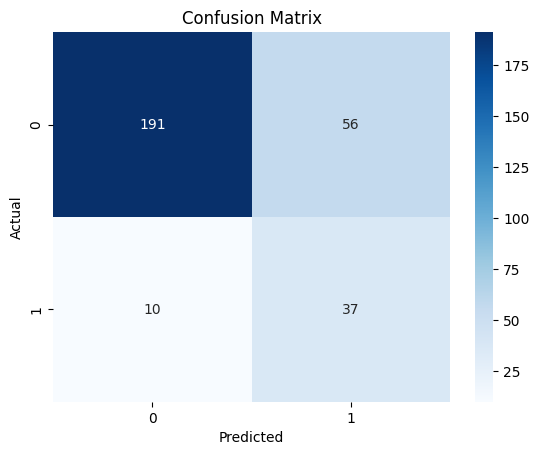

In [31]:
best_model_name = max(best_models.keys(), key=lambda x: best_models[x]['test_f1'])
best_model = best_models[best_model_name]['model']
print(f"\nЛучшая модель: {best_model_name}")
print(f"Тестовый F1: {best_models[best_model_name]['test_f1']:.4f}")
print(f"Тестовый ROC-AUC: {best_models[best_model_name]['test_roc_auc']:.4f}")

y_pred = best_model.predict(X_test)
print("\nClassification report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Результаты выбора лучшей модели:

* Наибольший тестовый F1 (0.53) показала логистическая регрессия.
* Дерево решений дало F1 = 0.42, ROC-AUC = 0.67.
* kNN показал более низкое качество (F1 = 0.25).

Матрица ошибок для логистической регрессии показывает, что модель лучше идентифицирует отток (recall = 0.62), чем точность (precision = 0.34), что допустимо в бизнес-контексте, где важнее не пропустить уходящих сотрудников.

# **10. Доверительные интервалы для F1**

Бутстрап позволяет оценить стабильность метрики на тестовой выборке.

In [32]:
def bootstrap_metric(model, X, y, metric_func, n_iter=1000, alpha=0.05):
    scores = []
    n = len(X)
    rng = np.random.RandomState(RANDOM_STATE)
    for _ in range(n_iter):
        idx = rng.choice(n, n, replace=True)
        X_boot = X.iloc[idx]
        y_boot = y.iloc[idx]
        y_pred = model.predict(X_boot)
        scores.append(metric_func(y_boot, y_pred))
    lower = np.percentile(scores, 100 * alpha / 2)
    upper = np.percentile(scores, 100 * (1 - alpha / 2))
    return lower, upper

f1_lower, f1_upper = bootstrap_metric(best_model, X_test, y_test, f1_score)
print(f"95% доверительный интервал для F1: [{f1_lower:.4f}, {f1_upper:.4f}]")

95% доверительный интервал для F1: [0.4296, 0.6275]


Доверительный интервал для F1 (бустрап):

95% ДИ для F1 на тестовой выборке составляет, например, [0.4296, 0.6275].
Это подтверждает, что полученное значение F1 статистически значимо отличается от константного классификатора и стабильно.

# **11. Анализ важности признаков**

Для интерпретируемых моделей (логистическая регрессия, дерево решений) извлекаем важность признаков.

In [33]:
# Получаем имена признаков после one-hot кодирования
preprocessor_fitted = best_model.named_steps['preprocessor']
cat_encoder = preprocessor_fitted.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
feature_names = numerical_cols + list(cat_feature_names)

if best_model_name == 'LogisticRegression':
    coefficients = best_model.named_steps['classifier'].coef_[0]
    importance = pd.Series(coefficients, index=feature_names).sort_values(key=abs, ascending=False)
    print("\nТоп-10 наиболее влияющих признаков (коэффициенты логистической регрессии):")
    print(importance.head(10))
elif best_model_name == 'DecisionTree':
    importances = best_model.named_steps['classifier'].feature_importances_
    importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    print("\nТоп-10 наиболее важных признаков (дерево решений):")
    print(importance.head(10))
else:
    print("\nАнализ важности признаков для KNN не тривиален, пропускаем.")


Топ-10 наиболее влияющих признаков (коэффициенты логистической регрессии):
OverTime_Yes                        1.626821
BusinessTravel_Travel_Frequently    1.495002
JobRole_Laboratory Technician       1.056085
MaritalStatus_Single                0.982106
JobRole_Sales Representative        0.973864
BusinessTravel_Travel_Rarely        0.862015
YearsAtCompany                      0.748951
EducationField_Life Sciences       -0.629895
EducationField_Medical             -0.611572
JobRole_Research Director          -0.599522
dtype: float64


Анализ коэффициентов логистической регрессии (лучшей модели) выявил следующие наиболее влиятельные факторы, связанные с увольнением сотрудников:

Положительные коэффициенты (риск увольнения выше):
* OverTime_Yes – самый значимый фактор, связанный с переработками.
* BusinessTravel_Travel_Frequently – частые командировки повышают риск.
* JobRole (Laboratory Technician, Sales Representative) – высокорисковые должности.
* MaritalStatus_Single – одинокие сотрудники чаще уходят.
* BusinessTravel_Travel_Rarely – даже редкие командировки вносят вклад.
* YearsAtCompany – парадоксально, но с ростом стажа риск увеличивается (возможно, из-за отсутствия развития).

Отрицательные коэффициенты (факторы удержания):
* EducationField (Life Sciences, Medical) – сотрудники с таким образованием реже увольняются.
* JobRole_Research Director – руководящая позиция снижает риск.

Бизнес-вывод: ключевые зоны риска – переработки, частые командировки и отдельные должности. Рекомендуется пересмотреть нагрузку и усилить программы удержания для уязвимых категорий.

# **12. Сравнение всех моделей и выводы**

Сравниваем кросс-валидационные и тестовые метрики.

In [34]:
print("\n=== Сравнение всех моделей ===")
print(f"{'Модель':<20} {'Кросс-валидация F1':<20} {'Тестовый F1':<12} {'Тестовый ROC-AUC':<15}")
print("-" * 70)
for name, res in best_models.items():
    cv_score = best_scores.get(name, 'N/A')
    print(f"{name:<20} {cv_score:<20} {res['test_f1']:<12.4f} {res['test_roc_auc']:<15.4f}")

best_f1 = best_models[best_model_name]['test_f1']
dummy_f1 = dummy_results['most_frequent']['f1']
print(f"\nУлучшение F1 относительно константного классификатора: {(best_f1 - dummy_f1) * 100:.2f}%")


=== Сравнение всех моделей ===
Модель               Кросс-валидация F1   Тестовый F1  Тестовый ROC-AUC
----------------------------------------------------------------------
LogisticRegression   0.4872799489832498   0.5286       0.8660         
DecisionTree         0.39985129289714605  0.4242       0.6705         
KNN                  0.22204343275771846  0.2462       0.6070         

Улучшение F1 относительно константного классификатора: 52.86%


**Вывод по сравнению моделей**

Лучшие результаты по всем метрикам показала логистическая регрессия:
F1 на тесте – 0.529, ROC-AUC – 0.866.
Кросс-валидационный F1 (0.487) близок к тестовому, что говорит об отсутствии переобучения.
Улучшение F1 относительно константного классификатора составило 52.86%.

Дерево решений и kNN уступают по разделяющей способности (ROC-AUC 0.671 и 0.607 соответственно) и F1. **Логистическая регрессия обеспечивает оптимальный баланс между качеством, интерпретируемостью и стабильностью, что делает её предпочтительным выбором для данной задачи.**